# Metrics Development

## 1. Setup

Imports and shared helpers used throughout the notebook.

In [1]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import umap
from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

data_path = "../outputs/%s/data/"


/users/mbredber/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Single-Run Exploration

### 2.1 Load data

Analyse the projections and labels produced by a single training run.

Edit `run_directory` in the first cell to point at any output folder.

In [2]:
# Specify the run directory
run_directory='/users/mbredber/p3_SUPLAT/outputs/run_cnxt_mlp_pond_step_wd_20260508_1629'

# Extract the run name from the directory path
run_name = Path(run_directory).name

# Extract project_location
project_location = Path(run_directory).parent.parent

# Load test data
test_proj = np.load(data_path % run_name + "test_projections.npy")                                         
test_labels = np.load(data_path % run_name + "test_labels.npy")  
print("test_proj shape:", test_proj.shape)
print("test_labels shape:", test_labels.shape)

test_proj shape: (1024, 256)
test_labels shape: (1024, 5)


### 2.2 Class masks
Build boolean masks isolating FRI-only, FRII-only, and Hybrid sources from the multi-label array.

In [3]:
# Mask for FRI only, FRII only, and hybrid
mask_fri = (test_labels[:,0] == 1) & (test_labels[:,1] == 0) & (test_labels[:,2] == 0)
mask_frii = (test_labels[:,0] == 0) & (test_labels[:,1] == 1) & (test_labels[:,2] == 0)
mask_hybrid = test_labels[:, 2] == 1 #OK

# Combine them
combined_mask = mask_fri | mask_frii | mask_hybrid
print(mask_fri.shape, combined_mask.shape)

(1024,) (1024,)


### 2.3 Clustering metrics

Silhouette score, Davies-Bouldin index, and Calinski-Harabasz score on the test projections. Higher silhouette / Calinski-Harabasz and lower Davies-Bouldin indicate better-separated clusters.

Multi-hot labels are collapsed to a single integer class via `argmax` before scoring.

In [ ]:
test_labels_single = np.argmax(test_labels[combined_mask], axis=1)

silhouette = silhouette_score(test_proj[combined_mask], test_labels_single)
print("Silhouette Score:", silhouette)

davies_bouldin = davies_bouldin_score(test_proj[combined_mask], test_labels_single)
print("Davies-Bouldin Score:", davies_bouldin)

calinski_harabasz = calinski_harabasz_score(test_proj[combined_mask], test_labels_single)
print("Calinski-Harabasz Score:", calinski_harabasz)

### 2.4 Pairwise distance distributions
Histograms of embedding distances between every pair of class combinations (FRI–FRII, FRI–Hybrid, FRII–Hybrid). A well-trained model should show clear separation.

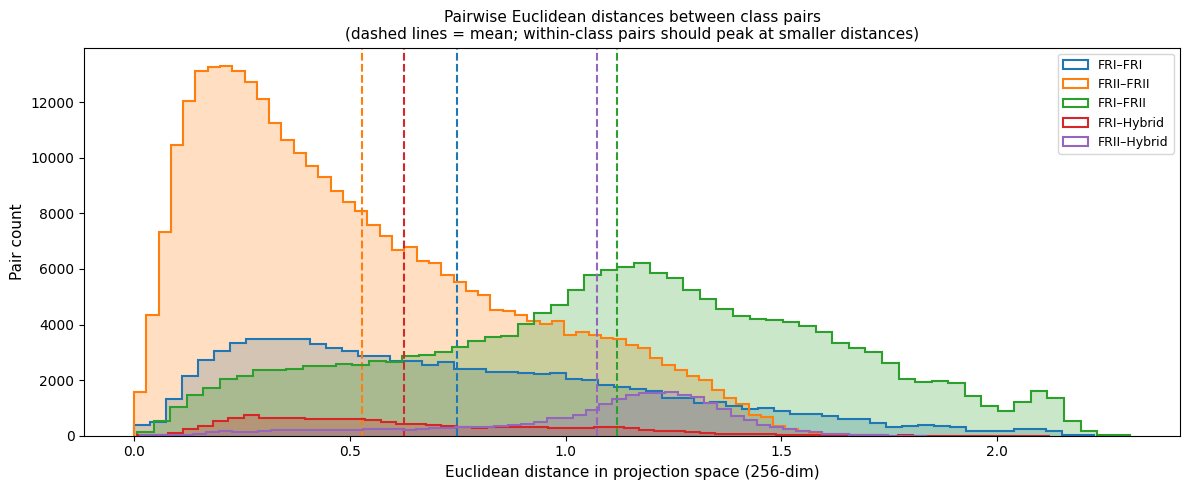

In [5]:
# Pairwise Euclidean distances in the projection space
proj_dim  = test_proj.shape[1]
distances = squareform(pdist(test_proj[combined_mask], metric='euclidean'))

# Indices for each class
indices_fri    = np.where(test_labels_single == 0)[0]
indices_frii   = np.where(test_labels_single == 1)[0]
indices_hybrid = np.where(test_labels_single == 2)[0]

# Within-class and between-class distance distributions
pairs = {
    'FRI–FRI':     distances[np.ix_(indices_fri,    indices_fri)].flatten(),
    'FRII–FRII':   distances[np.ix_(indices_frii,   indices_frii)].flatten(),
    'FRI–FRII':    distances[np.ix_(indices_fri,    indices_frii)].flatten(),
    'FRI–Hybrid':  distances[np.ix_(indices_fri,    indices_hybrid)].flatten(),
    'FRII–Hybrid': distances[np.ix_(indices_frii,   indices_hybrid)].flatten(),
}

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10.colors

for (label, d), color in zip(pairs.items(), colors):
    ax.hist(d, bins=60, alpha=0.25, color=color)                           # filled background
    ax.hist(d, bins=60, histtype='step', color=color, linewidth=1.5,       # solid outline
            label=label)
    ax.axvline(np.mean(d), color=color, linestyle='--', linewidth=1.5)

ax.set_xlabel(f'Euclidean distance in projection space ({proj_dim}-dim)', fontsize=11)
ax.set_ylabel('Pair count', fontsize=11)
ax.set_title(
    'Pairwise Euclidean distances between class pairs\n'
    '(dashed lines = mean; within-class pairs should peak at smaller distances)',
    fontsize=11,
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 3. Dimensionality Reduction

### 3.1 Interactive UMAP viewer

In [6]:
RUN_SECTION_3 = False   # set to True to run dimensionality-reduction cells


Visualise the learned embedding space in 2-D using UMAP and t-SNE.

Colour encodes morphological class; the gold-bordered point marks the query anchor in the KNN gallery.

In [7]:
if RUN_SECTION_3:
    # run_name is set in §2.1 — edit it there to change which run is visualised
    splits         = ['train', 'test']   # any subset of ['train', 'val', 'test']
    use_train_umap = True
    n_neighbors    = 30
    min_dist       = 0.1

    embed_dir = Path("../outputs") / run_name / "data"

    split_files = {
        'train': ('train_projections.npy', 'train_labels.npy'),
        'val':   ('val_projections.npy',   'val_labels.npy'),
        'test':  ('test_projections.npy',  'test_labels.npy'),
    }

    def pure_mask(labels):
        """Boolean mask for FRI-only, FRII-only, and Hybrid rows."""
        fri    = (labels[:, 0] == 1) & (labels[:, 1] == 0) & (labels[:, 2] == 0)
        frii   = (labels[:, 0] == 0) & (labels[:, 1] == 1) & (labels[:, 2] == 0)
        hybrid =  labels[:, 2] == 1
        return fri | frii | hybrid

    data = {}
    for s in splits:
        proj_file, lbl_file = split_files[s]
        proj   = np.load(embed_dir / proj_file)
        labels = np.load(embed_dir / lbl_file)
        mask   = pure_mask(labels)
        data[s] = {'proj': proj, 'labels': labels, 'mask': mask}

    if use_train_umap:
        if 'train' not in data:
            raise ValueError("use_train_umap=True requires 'train' in splits")
        train_proj_masked = data['train']['proj'][data['train']['mask']]
        reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist,
                            metric='euclidean', random_state=42)
        data['train']['embedding'] = reducer.fit_transform(train_proj_masked)
        for s in splits:
            if s == 'train':
                continue
            data[s]['embedding'] = reducer.transform(data[s]['proj'][data[s]['mask']])
    else:
        for s in splits:
            data[s]['embedding'] = UMAP_embedding(
                data[s]['proj'][data[s]['mask']], n_neighbors=n_neighbors, min_dist=min_dist
            )

    fig, axes = plt.subplots(1, len(splits), figsize=(5 * len(splits), 4), squeeze=False)
    axes = axes[0]

    colors = {'FRI': 'red', 'FRII': 'blue', 'Hybrid': 'green'}
    umap_label = "train UMAP space" if use_train_umap else "independent UMAP"

    for ax, s in zip(axes, splits):
        emb    = data[s]['embedding']
        labels = data[s]['labels'][data[s]['mask']]
        ax.scatter(emb[labels[:, 0] == 1, 0], emb[labels[:, 0] == 1, 1],
                   c=colors['FRI'],    s=2, alpha=0.7, label='FRI')
        ax.scatter(emb[labels[:, 1] == 1, 0], emb[labels[:, 1] == 1, 1],
                   c=colors['FRII'],   s=2, alpha=0.7, label='FRII')
        ax.scatter(emb[labels[:, 2] == 1, 0], emb[labels[:, 2] == 1, 1],
                   c=colors['Hybrid'], s=2, alpha=0.7, label='Hybrid')
        ax.set_title(f"{s}  [{umap_label}]")
        ax.legend(markerscale=4, fontsize=8)
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")

    fig.suptitle(run_name, fontsize=10)
    plt.tight_layout()
    plt.show()


### 3.2 UMAP helper & hyperparameter sweep
Wraps `umap.UMAP` in a single callable. The sweep below varies `min_dist` to find a visually informative layout.

In [8]:
if RUN_SECTION_3:
    def UMAP_embedding(embeddings, n_neighbors=15, min_dist=0.1):
        reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric='euclidean')
        return reducer.fit_transform(embeddings)

    n_neighbors_values = [5, 10, 20, 30, 100]
    plt.figure(figsize=(16, 4))
    for i, n_neighbors in enumerate(n_neighbors_values):
        embedding_2d = UMAP_embedding(test_proj[combined_mask], n_neighbors=n_neighbors, min_dist=0.1)
        plt.subplot(1, 5, i + 1)
        plt.scatter(embedding_2d[test_labels_single == 0, 0], embedding_2d[test_labels_single == 0, 1], c='red', label='FRI', alpha=0.7, s=1)
        plt.scatter(embedding_2d[test_labels_single == 1, 0], embedding_2d[test_labels_single == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
        plt.scatter(embedding_2d[test_labels_single == 2, 0], embedding_2d[test_labels_single == 2, 1], c='green', label='Hybrid', alpha=0.7, s=1)
        plt.legend()
        plt.title(f'n_neighbors: {n_neighbors}')
    plt.show()


### 3.3 `min_dist` sweep
Five projections with `min_dist` ∈ {0.01, 0.05, 0.1, 0.5, 0.9} at fixed `n_neighbors=50`. Smaller values pack clusters tighter; larger values preserve global topology.

In [9]:
if RUN_SECTION_3:
    min_dist_values = [0.01, 0.05, 0.1, 0.5, 0.9]
    plt.figure(figsize=(16, 4))
    for i, min_dist in enumerate(min_dist_values):
        embedding_2d = UMAP_embedding(test_proj[combined_mask], n_neighbors=50, min_dist=min_dist)
        plt.subplot(1, 5, i + 1)
        plt.scatter(embedding_2d[test_labels_single == 0, 0], embedding_2d[test_labels_single == 0, 1], c='red', label='FRI', alpha=0.7, s=1)
        plt.scatter(embedding_2d[test_labels_single == 1, 0], embedding_2d[test_labels_single == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
        plt.scatter(embedding_2d[test_labels_single == 2, 0], embedding_2d[test_labels_single == 2, 1], c='green', label='Hybrid', alpha=0.7, s=1)
        plt.legend()
        plt.title(f'min_dist: {min_dist}')
    plt.show()


### 3.4 Best-case projections — train vs test
UMAP at the best hyperparameters (`n_neighbors=30`, `min_dist=0.1`) for both the *both* and *either* loss variants. Train is shown at full size, 2 400, and 1 000 samples to check for density effects.

In [10]:
if RUN_SECTION_3:
    n_neighbors = 30
    min_dist = 0.1
    test_proj_both = np.load(data_path % run_name + "test_projections.npy")
    test_labels_both = np.load(data_path % run_name + "test_labels.npy")
    train_proj_both = np.load(data_path % run_name + "train_projections.npy")
    train_labels_both = np.load(data_path % run_name + "train_labels.npy")

    mask_fri_test = (test_labels_both[:,0] == 1) & (test_labels_both[:,1] == 0) & (test_labels_both[:,2] == 0)
    mask_frii_test = (test_labels_both[:,0] == 0 ) & (test_labels_both[:,1] == 1) & (test_labels_both[:,2] == 0)
    mask_hybrid_test = test_labels_both[:, 2] == 1
    mask_fri_train = (train_labels_both[:,0] == 1) & (train_labels_both[:,1] == 0) & (train_labels_both[:,2] == 0)
    mask_frii_train = (train_labels_both[:,0] == 0) & (train_labels_both[:,1] == 1) & (train_labels_both[:,2] == 0)
    mask_hybrid_train = train_labels_both[:, 2] == 1
    combined_mask_test = mask_fri_test | mask_frii_test | mask_hybrid_test
    combined_mask_train = mask_fri_train | mask_frii_train | mask_hybrid_train
    print(combined_mask_test.shape, combined_mask_train.shape)

    embedding_2d_test_both = UMAP_embedding(test_proj_both[combined_mask_test], n_neighbors=n_neighbors, min_dist=min_dist)
    embedding_2d_train_both = UMAP_embedding(train_proj_both[combined_mask_train], n_neighbors=n_neighbors, min_dist=min_dist)

    plt.figure(figsize=(12, 3))
    plt.subplot(1, 4, 1)
    plt.scatter(embedding_2d_test_both[test_labels_both[combined_mask_test][:,0] == 1, 0], embedding_2d_test_both[test_labels_both[combined_mask_test][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
    plt.scatter(embedding_2d_test_both[test_labels_both[combined_mask_test][:,1] == 1, 0], embedding_2d_test_both[test_labels_both[combined_mask_test][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    plt.scatter(embedding_2d_test_both[test_labels_both[combined_mask_test][:,2] == 1, 0], embedding_2d_test_both[test_labels_both[combined_mask_test][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    plt.legend()
    plt.title(f'Both - Test')
    for i, n_samples in enumerate([combined_mask_train.shape[0], 2400, 1000]):
        if n_samples < combined_mask_train.shape[0]:
            indices = np.random.choice(np.where(combined_mask_train)[0], size=n_samples, replace=False)
        else:
            indices = np.where(combined_mask_train)[0]
        embedding_2d_train_both_sample = UMAP_embedding(train_proj_both[indices], n_neighbors=n_neighbors, min_dist=min_dist)
        plt.subplot(1, 4, i + 2)
        plt.scatter(embedding_2d_train_both_sample[train_labels_both[indices][:,0] == 1, 0], embedding_2d_train_both_sample[train_labels_both[indices][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
        plt.scatter(embedding_2d_train_both_sample[train_labels_both[indices][:,1] == 1, 0], embedding_2d_train_both_sample[train_labels_both[indices][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
        plt.scatter(embedding_2d_train_both_sample[train_labels_both[indices][:,2] == 1, 0], embedding_2d_train_both_sample[train_labels_both[indices][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
        plt.legend()
        plt.title(f'Both - Train - {n_samples} samples')
    plt.tight_layout()
    plt.show()


### 3.5 t-SNE comparison
t-SNE (`perplexity=25`) on the same embeddings as §3.4 for a second opinion on cluster structure. t-SNE is more expensive but can reveal finer local neighbourhood detail.

In [11]:
if RUN_SECTION_3:
    embedding_2d_test_both_tsne = TSNE(n_components=2, perplexity=25).fit_transform(test_proj_both[combined_mask_test])
    embedding_2d_train_both_tsne = TSNE(n_components=2, perplexity=25).fit_transform(train_proj_both[combined_mask_train])
    plt.figure(figsize=(12, 3))
    plt.subplot(1, 4, 1)
    plt.scatter(embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,0] == 1, 0], embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
    plt.scatter(embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,1] == 1, 0], embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
    plt.scatter(embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,2] == 1, 0], embedding_2d_test_both_tsne[test_labels_both[combined_mask_test][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
    plt.legend()
    plt.title('Both - Test - tSNE')
    for i, n_samples in enumerate([combined_mask_train.shape[0], 2400, 1000]):
        if n_samples < combined_mask_train.shape[0]:
            indices = np.random.choice(np.where(combined_mask_train)[0], size=n_samples, replace=False)
        else:
            indices = np.where(combined_mask_train)[0]
        embedding_2d_train_both_sample_tsne = TSNE(n_components=2, perplexity=30).fit_transform(train_proj_both[indices])
        plt.subplot(1, 4, i + 2)
        plt.scatter(embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,0] == 1, 0], embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,0] == 1, 1], c='red', label='FRI', alpha=0.7, s=1)
        plt.scatter(embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,1] == 1, 0], embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,1] == 1, 1], c='blue', label='FRII', alpha=0.7, s=1)
        plt.scatter(embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,2] == 1, 0], embedding_2d_train_both_sample_tsne[train_labels_both[indices][:,2] == 1, 1], c='green', label='Hybrid', alpha=0.7, s=1)
        plt.title(f'Both - Train - {n_samples} samples - tSNE')
    plt.tight_layout()
    plt.show()


## 4. Nearest-Neighbour & Distance Analysis

### 4.1 KNN image gallery

Quantify how well the embedding space organises sources by morphology. Variables `run_directory`, `run_name`, and `project_location` carry over from §2.1.

§4.1 shows raw image neighbours for generated and real sources; §4.2–4.3 correlate embedding distance with label overlap.

In [ ]:
split           = 'val'   # real split to search against
N               = 5       # number of generated images to show
seed            = 42
GEN_CACHE       = Path('..') / 'notebooks' / 'outputs'
GEN_LABEL_NAMES = None    # e.g. ['FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles']

import sys
import torch
sys.path.insert(0, str(Path('..') / 'src'))
from suplat.models.byol_models import (
    BYOLEfficient, BYOLEfficientNetB0, BYOLPretrainedBackbone,
    create_resnet18_backbone, create_resnet50_backbone,
    create_convnext_tiny_backbone, PCAProjection,
)

ALL_CLASS_NAMES = [
    'FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles',
    'C-curv', 'S-curv', 'Misalign', 'Wings', 'X-shaped',
    'Straight jets', 'Multi hotspots', 'Cont. jets', 'Banding',
    'One-sided', 'Restarted', 'Cluster', 'Merger', 'Diffuse', 'Unknown',
]

assert (GEN_CACHE / 'gen_generated.npy').exists(), \
    "Run Cell A in generative_modelling.ipynb first to create the image caches."
gen_imgs = np.load(GEN_CACHE / 'gen_generated.npy').astype(np.float32)
gen_lbls = np.load(GEN_CACHE / 'gen_labels.npy') if (GEN_CACHE / 'gen_labels.npy').exists() else None
if gen_imgs.max() > 1.5:
    gen_imgs /= 255.0

n_gen_labels  = gen_lbls.shape[1] if gen_lbls is not None else 0
gen_lbl_names = (GEN_LABEL_NAMES if GEN_LABEL_NAMES is not None
                 else ALL_CLASS_NAMES if n_gen_labels == 20
                 else [str(i) for i in range(n_gen_labels)])

images_full = np.load(f'{project_location}/data/preprocessed/lotss/images_filtered.npy')
emb_dir     = f'{project_location}/outputs/{run_name}/data/'
real_projs  = np.load(emb_dir + f'{split}_projections.npy')
real_labels = np.load(emb_dir + f'{split}_labels.npy')

split_idx = np.load(emb_dir + f'{split}_idx.npy')
real_imgs = images_full[split_idx]

n_real_labels    = real_labels.shape[1] if real_labels.ndim > 1 else 1
real_label_names = ALL_CLASS_NAMES[:n_real_labels]

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt_path = Path(run_directory) / 'byol_model_best.pt'

def _load_byol(path, device):
    def _strip(sd):
        p = '_orig_mod.'
        return {k[len(p):] if k.startswith(p) else k: v for k, v in sd.items()} \
               if any(k.startswith(p) for k in sd) else sd
    ckpt = torch.load(path, map_location=device, weights_only=False)
    sd   = _strip(ckpt['model_state_dict'])
    if   any('features.1.0.block.0.0.weight' in k for k in sd): mtype = 'efficientnet-b0'
    elif any('layer1.0.conv1.weight'          in k for k in sd):
        w = sd.get('online_predictor.net.0.weight')
        mtype = 'resnet50' if w is not None and w.shape[1] == 2048 else 'resnet18'
    elif any('online_encoder.conv1.weight'    in k for k in sd): mtype = 'convnet'
    else:                                                          mtype = 'convnext-tiny'
    pmode = 'pca' if 'online_projector.mean_' in sd else 'mlp'
    pdim  = int(sd['online_predictor.net.0.weight'].shape[1]) if 'online_predictor.net.0.weight' in sd else 256
    if   mtype == 'convnet':        model = BYOLEfficient(feature_compression_mode=pmode, projection_dim=pdim)
    elif mtype == 'efficientnet-b0': model = BYOLEfficientNetB0(feature_compression_mode=pmode, projection_dim=pdim)
    elif mtype == 'resnet18':
        bb, enc = create_resnet18_backbone(num_channels=1)
        model = BYOLPretrainedBackbone(bb, encoder_dim=enc, projection_dim=pdim, feature_compression_mode=pmode)
    elif mtype == 'resnet50':
        bb, enc = create_resnet50_backbone(num_channels=1)
        model = BYOLPretrainedBackbone(bb, encoder_dim=enc, projection_dim=pdim, feature_compression_mode=pmode)
    else:
        bb, enc = create_convnext_tiny_backbone(num_channels=1)
        model = BYOLPretrainedBackbone(bb, encoder_dim=enc, projection_dim=pdim, feature_compression_mode=pmode)
    if pmode == 'pca':
        for pfx in ('online_projector', 'target_projector'):
            proj = getattr(model, pfx, None)
            if isinstance(proj, PCAProjection):
                for buf in ('mean_', 'components_', 'active_mask_'):
                    key = f'{pfx}.{buf}'
                    if key in sd: proj.register_buffer(buf, sd[key].clone())
                proj._fitted = True
                if not hasattr(proj, 'active_mask_'):
                    proj.register_buffer('active_mask_', torch.ones(proj.mean_.shape[0], dtype=torch.bool))
    model.load_state_dict(sd)
    model.eval().to(device)
    for p in model.parameters(): p.requires_grad = False
    return model

if '_byol_gen_gallery' not in dir() or _byol_gen_gallery is None:
    print(f'Loading BYOL from {ckpt_path.name}…')
    _byol_gen_gallery = _load_byol(ckpt_path, device)
else:
    print('Using cached BYOL model.')

def _encode(imgs, model, device, bs=128):
    out = []
    t = torch.from_numpy(imgs[:, None])
    with torch.no_grad():
        for i in range(0, len(t), bs):
            x = t[i:i+bs].to(device)
            out.append(model.online_projector(model.online_encoder(x)).cpu().numpy())
    return np.concatenate(out)

print('Encoding generated images…')
gen_projs = _encode(gen_imgs, _byol_gen_gallery, device)
print(f'  gen_projs: {gen_projs.shape}  |  real_projs: {real_projs.shape}')
print(f'  real label dims: {n_real_labels}  ({", ".join(real_label_names)})')

nn_model     = NearestNeighbors(n_neighbors=8, metric='euclidean').fit(real_projs)
rng          = np.random.default_rng(seed)
sel_idxs     = rng.choice(len(gen_projs), size=N, replace=False)
_, knn_indices = nn_model.kneighbors(gen_projs[sel_idxs])

def wrap_label(s, max_chars=18):
    parts = [p.strip() for p in s.split(',')]
    lines, cur = [], ''
    for p in parts:
        cand = f'{cur}, {p}' if cur else p
        if len(cand) > max_chars and cur:
            lines.append(cur); cur = p
        else:
            cur = cand
    if cur: lines.append(cur)
    return '\n'.join(lines)

cell_size  = 1.6
left_mar, right_mar, top_mar, bottom_mar = 0.02, 0.02, 0.10, 0.02

fig, axes = plt.subplots(
    3, 3 * N,
    figsize=(cell_size * 3 * N, cell_size * 3 + 0.5),
    gridspec_kw={'wspace': 0.03, 'hspace': 0.08},
)
fig.subplots_adjust(left=left_mar, right=1-right_mar,
                    top=1-top_mar, bottom=bottom_mar)

for i, gi in enumerate(sel_idxs):
    nn_idxs    = knn_indices[i]
    col_offset = i * 3
    grid = [nn_idxs[0], nn_idxs[1], nn_idxs[2],
            nn_idxs[3], None,        nn_idxs[4],
            nn_idxs[5], nn_idxs[6], nn_idxs[7]]

    gen_active = ([gen_lbl_names[j] for j, v in enumerate(gen_lbls[gi]) if v > 0.5]
                  if gen_lbls is not None else [])
    gen_tag    = ', '.join(gen_active) if gen_active else '—'
    axes[0, col_offset + 1].set_title(
        wrap_label(gen_tag, max_chars=22), fontsize=9, fontweight='bold', pad=4
    )

    for flat_pos, real_idx in enumerate(grid):
        row     = flat_pos // 3
        col_pos = col_offset + (flat_pos % 3)
        ax      = axes[row, col_pos]

        if real_idx is None:
            ax.imshow(gen_imgs[gi], cmap='viridis', origin='lower')
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('gold')
                spine.set_linewidth(3)
            ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])
            ax.text(0.02, 0.02, wrap_label(gen_tag), transform=ax.transAxes,
                    fontsize=6, color='white', va='bottom', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='#9a7200', alpha=0.75, pad=1, linewidth=0))
        else:
            ax.imshow(real_imgs[real_idx], cmap='viridis', origin='lower')
            ax.axis('off')
            lbl    = real_labels[real_idx]
            active = [real_label_names[j] for j in range(n_real_labels) if lbl[j] == 1]
            ax.text(0.02, 0.02, wrap_label(', '.join(active) if active else '—'),
                    transform=ax.transAxes, fontsize=6, color='white',
                    va='bottom', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1, linewidth=0))

    if i < N - 1:
        plot_width = 1 - left_mar - right_mar
        x_sep = left_mar + plot_width * (col_offset + 3) / (3 * N)
        fig.add_artist(plt.matplotlib.lines.Line2D(
            [x_sep, x_sep], [bottom_mar, 1 - top_mar],
            transform=fig.transFigure,
            color='grey', linewidth=0.8, linestyle='--', zorder=10,
        ))

print(f'Run: {run_name}  |  split: {split}')
fig.suptitle(f'Generated ★ (yellow) ↔ 8 nearest real in embedding  |  {split}',
             fontsize=11, y=0.995)
plt.show()

### 4.1b KNN Gallery — real sources

For each of `N` randomly sampled morphology classes, shows the anchor source (gold border) and its 8 nearest neighbours in embedding space. Set `split` and `seed` below.

In [ ]:
split    = 'test'
N        = 5
seed     = 42

ALL_CLASS_NAMES = [
    'FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles',
    'C-curv', 'S-curv', 'Misalign', 'Wings', 'X-shaped',
    'Straight jets', 'Multi hotspots', 'Cont. jets', 'Banding', 'One-sided', 'Restarted',
    'Cluster', 'Merger', 'Diffuse', 'Unknown',
]

images_full = np.load(f'{project_location}/data/preprocessed/lotss/images_filtered.npy')
emb_dir     = f'{project_location}/outputs/{run_name}/data/'
projections = np.load(emb_dir + f'{split}_projections.npy')
labels      = np.load(emb_dir + f'{split}_labels.npy')

split_idx = np.load(emb_dir + f'{split}_idx.npy')
images = images_full[split_idx]

n_label_cols = labels.shape[1] if labels.ndim > 1 else 1
label_names  = ALL_CLASS_NAMES[:n_label_cols]

rng = np.random.default_rng(seed)
positive_counts = (labels == 1).sum(axis=0)
valid_cols   = np.where(positive_counts >= 1)[0]
sampled_cols = rng.choice(valid_cols, size=N, replace=False)

nn_model = NearestNeighbors(n_neighbors=9, metric='euclidean').fit(projections)

print(f'Run: {run_name}  |  split: {split}  |  labels: {label_names}')

def wrap_label(label_str, max_chars=18):
    parts = [s.strip() for s in label_str.split(',')]
    lines, current = [], ''
    for part in parts:
        candidate = f'{current}, {part}' if current else part
        if len(candidate) > max_chars and current:
            lines.append(current)
            current = part
        else:
            current = candidate
    if current:
        lines.append(current)
    return '\n'.join(lines)

cell_size  = 1.6
left_mar, right_mar, top_mar, bottom_mar = 0.02, 0.02, 0.10, 0.02

fig, axes = plt.subplots(
    3, 3 * N,
    figsize=(cell_size * 3 * N, cell_size * 3 + 0.5),
    gridspec_kw={'wspace': 0.03, 'hspace': 0.08}
)
fig.subplots_adjust(left=left_mar, right=1 - right_mar,
                    top=1 - top_mar, bottom=bottom_mar)

for i, col in enumerate(sampled_cols):
    anchor_idx = int(rng.choice(np.where(labels[:, col] == 1)[0]))
    _, indices = nn_model.kneighbors(projections[anchor_idx:anchor_idx + 1])
    nn_idxs = indices[0][1:]

    grid_idxs = [nn_idxs[0], nn_idxs[1], nn_idxs[2],
                 nn_idxs[3], anchor_idx,  nn_idxs[4],
                 nn_idxs[5], nn_idxs[6], nn_idxs[7]]

    col_offset = i * 3
    axes[0, col_offset + 1].set_title(label_names[col], fontsize=10, fontweight='bold', pad=4)

    for flat_pos, data_idx in enumerate(grid_idxs):
        ax = axes[flat_pos // 3, col_offset + (flat_pos % 3)]
        ax.imshow(images[data_idx], cmap='viridis', origin='lower')
        ax.axis('off')

        if data_idx == anchor_idx:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('gold')
                spine.set_linewidth(3)
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])

        lbl    = labels[data_idx]
        active = [label_names[j] for j in range(n_label_cols) if lbl[j] == 1]
        tag    = wrap_label(', '.join(active)) if active else '—'
        ax.text(0.02, 0.02, tag, transform=ax.transAxes,
                fontsize=6, color='white', va='bottom', ha='left', linespacing=1.3,
                bbox=dict(facecolor='black', alpha=0.5, pad=1, linewidth=0))

    if i < N - 1:
        plot_width = 1 - left_mar - right_mar
        x_sep = left_mar + plot_width * (col_offset + 3) / (3 * N)
        fig.add_artist(plt.matplotlib.lines.Line2D(
            [x_sep, x_sep], [bottom_mar, 1 - top_mar],
            transform=fig.transFigure,
            color='grey', linewidth=0.8, linestyle='--', zorder=10
        ))

fig.suptitle(f'KNN Gallery  |  {split}', fontsize=11, y=0.995)
plt.show()

### 4.2 Cosine distance vs Hamming distance
Scatter plot of cosine distance in embedding space against Hamming distance between multi-hot label vectors for up to 300 000 random test-set pairs. A well-trained model should show a positive correlation.

In [ ]:
split     = 'test'
MAX_PAIRS = 300_000
seed      = 42

emb_dir = Path(f'../outputs/{run_name}/data')
proj    = np.load(emb_dir / f'{split}_projections.npy')
labels  = np.load(emb_dir / f'{split}_labels.npy')

cos_d  = pdist(proj,   metric='cosine')
ham_d  = (pdist(labels, metric='hamming') * labels.shape[1]).round().astype(int)

rho, pval = spearmanr(cos_d, ham_d)

rng = np.random.default_rng(seed)
idx = rng.choice(len(cos_d), size=min(MAX_PAIRS, len(cos_d)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hb = axes[0].hexbin(cos_d[idx], ham_d[idx], gridsize=60, cmap='viridis', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='pair count')
axes[0].set_xlabel('Cosine distance (embedding)')
axes[0].set_ylabel('Hamming distance (labels)')
axes[0].set_title(f'Cosine vs Hamming  |  Spearman ρ = {rho:.3f}  (p={pval:.2e})')

unique_h = sorted(np.unique(ham_d))
data_by_h = [cos_d[ham_d == h] for h in unique_h]
vp = axes[1].violinplot(data_by_h, positions=unique_h, showmedians=True, showextrema=False)
axes[1].set_xlabel('Hamming distance (labels)')
axes[1].set_ylabel('Cosine distance (embedding)')
axes[1].set_title('Cosine dist distribution per Hamming distance')
axes[1].set_xticks(unique_h)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle(f'{run_name}  |  {split}', fontsize=10)
plt.tight_layout()
plt.show()

### 4.3 Cosine vs Hamming — per-tag filter

Same scatter as §4.2 but restricted to pairs where at least one source carries a specific tag. Adjust `TAG_COL` to inspect any of the 20 morphology classes. `run_name`, `split`, `MAX_PAIRS`, and `seed` are reused from §4.2.

In [ ]:
TAG_COL  = 1    # 0=FRI, 1=FRII, 2=Hybrids, 3=Spirals, 4=Relaxed doubles, ...

ALL_CLASS_NAMES = [
    'FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles',
    'C-curv', 'S-curv', 'Misalign', 'Wings', 'X-shaped',
    'Straight jets', 'Multi hotspots', 'Cont. jets', 'Banding', 'One-sided', 'Restarted',
    'Cluster', 'Merger', 'Diffuse', 'Unknown',
]

tag_name = ALL_CLASS_NAMES[TAG_COL]
tag_mask = labels[:, TAG_COL] == 1
proj_tag   = proj[tag_mask]
labels_tag = labels[tag_mask]
print(f'Tag "{tag_name}": {tag_mask.sum()} samples selected')

cos_d_tag = pdist(proj_tag,   metric='cosine')
ham_d_tag = (pdist(labels_tag, metric='hamming') * labels_tag.shape[1]).round().astype(int)

rho_tag, pval_tag = spearmanr(cos_d_tag, ham_d_tag)

idx_tag = rng.choice(len(cos_d_tag), size=min(MAX_PAIRS, len(cos_d_tag)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hb = axes[0].hexbin(cos_d_tag[idx_tag], ham_d_tag[idx_tag], gridsize=60, cmap='viridis', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='pair count')
axes[0].set_xlabel('Cosine distance (embedding)')
axes[0].set_ylabel('Hamming distance (labels)')
axes[0].set_title(f'Tag: {tag_name}  |  Spearman ρ = {rho_tag:.3f}  (p={pval_tag:.2e})')

unique_h_tag = sorted(np.unique(ham_d_tag))
data_by_h_tag = [cos_d_tag[ham_d_tag == h] for h in unique_h_tag]
axes[1].violinplot(data_by_h_tag, positions=unique_h_tag, showmedians=True, showextrema=False)
axes[1].set_xlabel('Hamming distance (labels)')
axes[1].set_ylabel('Cosine distance (embedding)')
axes[1].set_title(f'Distribution per Hamming dist  |  tag: {tag_name}')
axes[1].set_xticks(unique_h_tag)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle(f'{run_name}  |  {split}  |  filtered: {tag_name}', fontsize=10)
plt.tight_layout()
plt.show()

## 5. Multi-Run Comparison

### 5.1 Metric scores by loss weight

Compare clustering quality metrics across a sweep of loss hyperparameters or across entirely different runs.

§5.1 covers the metric-loss weight grid; §5.2–5.3 aggregate arbitrary output directories.

In [16]:
cases_both = [0.01, 0.1, 1, 10]
cases_either = [0, 0.25, 0.5, 0.75]

# compute silhouette, davies bouldin, calinski harabasz for each case, make a plot as a function of the case values
silhouette_scores = np.zeros((2, 4))
davies_bouldin_scores = np.zeros((2, 4))
calinski_harabasz_scores = np.zeros((2, 4))
for i, case in enumerate(cases_both):
    tmp_test_proj = np.load(data_path%f"run_both_w{case}" + "test_projections.npy")
    tmp_test_labels = np.load(data_path%f"run_both_w{case}" + "test_labels.npy")
    # Mask for FRI only, FRII only, and hybrid
    mask_fri = (tmp_test_labels[:,0] == 1) & (tmp_test_labels[:,1] == 0) & (tmp_test_labels[:,2] == 0)
    mask_frii = (tmp_test_labels[:,0] == 0) & (tmp_test_labels[:,1] == 1) & (tmp_test_labels[:,2] == 0)
    mask_hybrid = tmp_test_labels[:, 2] == 1 #OK
    # Combine them
    combined_mask = mask_fri | mask_frii | mask_hybrid
    test_labels_single = np.argmax(tmp_test_labels[combined_mask], axis=1)
    silhouette_scores[0, i] = silhouette_score(tmp_test_proj[combined_mask], test_labels_single)
    davies_bouldin_scores[0, i] = davies_bouldin_score(tmp_test_proj[combined_mask], test_labels_single)
    calinski_harabasz_scores[0, i] = calinski_harabasz_score(tmp_test_proj[combined_mask], test_labels_single)

for i, case in enumerate(cases_either):
    tmp_test_proj = np.load(data_path%f"run_either_p{case}" + "test_projections.npy")
    tmp_test_labels = np.load(data_path%f"run_either_p{case}" + "test_labels.npy")
    # Mask for FRI only, FRII only, and hybrid
    mask_fri = (tmp_test_labels[:,0] == 1) & (tmp_test_labels[:,1] == 0) & (tmp_test_labels[:,2] == 0)
    mask_frii = (tmp_test_labels[:,0] == 0) & (tmp_test_labels[:,1] == 1) & (tmp_test_labels[:,2] == 0)
    mask_hybrid = tmp_test_labels[:, 2] == 1 #OK
    # Combine them
    combined_mask = mask_fri | mask_frii | mask_hybrid
    test_labels_single = np.argmax(tmp_test_labels[combined_mask], axis=1)
    silhouette_scores[1, i] = silhouette_score(tmp_test_proj[combined_mask], test_labels_single)
    davies_bouldin_scores[1, i] = davies_bouldin_score(tmp_test_proj[combined_mask], test_labels_single)
    calinski_harabasz_scores[1, i] = calinski_harabasz_score(tmp_test_proj[combined_mask], test_labels_single)

cases_both = np.array(cases_both)
cases_either = np.array(cases_either)
# Plot the scores
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(cases_both, silhouette_scores[0], label='Both', marker='o')
plt.plot(cases_either/(1-cases_either)+1e-4, silhouette_scores[1], label='Either', marker='x')
plt.xlabel('w or p/(1-p)')
plt.title('Silhouette Score')
plt.xscale('log')
plt.xlim(0.005, 20)
plt.subplot(1, 3, 2)
plt.plot(cases_both, davies_bouldin_scores[0], label='Both', marker='o')
plt.plot(cases_either/(1-cases_either)+1e-4, davies_bouldin_scores[1], label='Either', marker='x')
plt.xlabel('w or p/(1-p)')
plt.title('Davies-Bouldin Score')
plt.xscale('log')
plt.xlim(0.005, 20)
plt.subplot(1, 3, 3)
plt.plot(cases_both, calinski_harabasz_scores[0], label='Both', marker='o')
plt.plot(cases_either/(1-cases_either)+1e-4, calinski_harabasz_scores[1], label='Either', marker='x')
plt.xlabel('w or p/(1-p)')
plt.title('Calinski-Harabasz Score')
plt.xscale('log')
plt.xlim(0.005, 20)
plt.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/run_both_w0.01/data/test_projections.npy'

### 5.2 Scan output directories
Walks the `outputs/` folder, parses every `metrics.json`, and collects results into a tidy structure ready for plotting.

In [ ]:
cwd = Path.cwd()
if cwd.name == "notebooks":
    outputs_dir = cwd.parent / "outputs"
else:
    outputs_dir = cwd / "outputs"

print(f"Using outputs dir: {outputs_dir}")

metrics_to_plot = ["silhouette", "davies_bouldin", "calinski_harabasz"]
dataset_key = "base_classes"

pattern = re.compile(
    r"^run_(both|either)_(closest|ponderate)_(initial|full)_(w|p)([0-9.]+)_s\d+_.*$"
)

raw = {}

for folder in outputs_dir.iterdir():
    if not folder.is_dir():
        continue

    name = folder.name
    if ("initial" not in name) and ("full" not in name):
        continue

    m = pattern.match(name)
    if m is None:
        continue

    _, weighting, scope, param_kind, param_value = m.groups()
    param_value = float(param_value)

    supervision = "either" if param_kind == "p" else "both"

    json_path = folder / "projection_metrics.json"
    if not json_path.exists():
        print(f"Missing json: {json_path}")
        continue

    with open(json_path, "r") as f:
        d = json.load(f)

    raw.setdefault(supervision, {}).setdefault(weighting, {}).setdefault(scope, [])

    raw[supervision][weighting][scope].append({
        "x": param_value,
        "train": {metric: d["train"][dataset_key][metric] for metric in metrics_to_plot},
        "test": {metric: d["test"][dataset_key][metric] for metric in metrics_to_plot},
        "folder": name,
    })

for supervision in raw:
    for weighting in raw[supervision]:
        for scope in raw[supervision][weighting]:
            xs = sorted(e["x"] for e in raw[supervision][weighting][scope])
            print(f"{supervision:6s} | {weighting:10s} | {scope:7s} | {xs}")

N_train = np.load('../outputs/run_both_closest_initial_p0.1_s97_20260323_1719/embeddings/train_projections.npy').shape[0]
N_test = np.load('../outputs/run_both_closest_initial_p0.1_s97_20260323_1719/embeddings/test_projections.npy').shape[0]
print(N_train, N_test)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False)

row_map = {"either": 0, "both": 1}
col_map = {
    "silhouette": 0,
    "davies_bouldin": 1,
    "calinski_harabasz": 2,
}

color_map = {
    "closest": "C0",
    "ponderate": "C1",
}

alpha_map = {
    "train": 0.4,
    "test": 1.0,
}

linestyle_map = {
    "initial": "--",
    "full": "-",
}

ylim_map = {
    "silhouette": [-0.1, 0.3],
    "davies_bouldin": [0, 10],
    "calinski_harabasz": [0,200],
}
    

for supervision in ["either", "both"]:
    for metric in metrics_to_plot:
        ax = axes[row_map[supervision], col_map[metric]]

        for weighting in ["closest", "ponderate"]:
            for scope in ["initial", "full"]:
                entries = raw.get(supervision, {}).get(weighting, {}).get(scope, [])
                if len(entries) == 0:
                    continue

                entries = sorted(entries, key=lambda e: e["x"])
                x = np.array([e["x"] for e in entries])

                for split in ["train", "test"]:
                    y = np.array([e[split][metric] for e in entries])
                    if metric=='calinski_harabasz' and split=='train':
                        y = y *N_test/N_train

                    ax.plot(
                        x, y,
                        color=color_map[weighting],
                        alpha=alpha_map[split],
                        linestyle=linestyle_map[scope],
                        linewidth=2,
                    )

        ax.set_title(metric.replace("_", " ").title())
        ax.grid(True, alpha=0.3)
        ax.set_ylim(ylim_map[metric])
        if supervision == "both":
            ax.set_xscale("log")
            ax.set_xlabel("w")
        else:
            ax.set_xlabel("p")

        if col_map[metric] == 0:
            ax.set_ylabel(supervision)

legend_elements = [
    Line2D([0], [0], color="C0", lw=2, label="Closest"),
    Line2D([0], [0], color="C1", lw=2, label="Ponderate"),
    Line2D([0], [0], color="black", lw=2, alpha=1.0, label="Test"),
    Line2D([0], [0], color="black", lw=2, alpha=0.4, label="Train"),
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Full"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Initial"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=6,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 5.3 Cross-run metric plot
Bar chart comparing silhouette, Davies-Bouldin, and Calinski-Harabasz across user-specified runs. Add paths to `RUN_DIRS` to include additional experiments.

In [ ]:
RUN_DIRS = [
    "/users/mbredber/p3_SUPLAT/outputs/GOOD_EN_old/GOOD_cond_base_20260402_1749",
    # add more directories here
]

def extract_run_name(path):
    name = Path(path).name
    name = re.sub(r'^(GOOD_|INTERESTING_|run_)', '', name)
    name = re.sub(r'_\d{8}_\d{4}$', '', name)
    return name

METRICS   = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
X_LABELS  = ['train\nfri_vs_frii', 'train\nbase_classes',
             'test\nfri_vs_frii',  'test\nbase_classes']
X_KEYS    = [('train','fri_vs_frii'), ('train','base_classes'),
             ('test','fri_vs_frii'),  ('test','base_classes')]

colors = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Multi-run projection metrics comparison', fontsize=13)

for run_idx, run_dir in enumerate(RUN_DIRS):
    metrics_path = Path(run_dir) / 'projection_metrics.json'
    with open(metrics_path) as f:
        data = json.load(f)
    run_name = extract_run_name(run_dir)
    color = colors[run_idx % len(colors)]

    for ax, metric in zip(axes, METRICS):
        values = [data[split][grouping][metric] for split, grouping in X_KEYS]
        ax.plot(range(len(X_KEYS)), values, marker='o', label=run_name, color=color)

for ax, metric in zip(axes, METRICS):
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xticks(range(len(X_LABELS)))
    ax.set_xticklabels(X_LABELS, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].legend(bbox_to_anchor=(0, -0.25), loc='upper left', ncol=3, fontsize=9)
fig.tight_layout()
plt.show()